In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from pymoo.visualization.pcp import PCP
from pymoo.util.normalization import normalize
from pymoo.visualization.scatter import Scatter
from pymoo.visualization.star_coordinate import StarCoordinate

# from optimization.problems.myProblem import SenActProblem

from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import MinMaxScaler


from pyrecorder.recorder import Recorder
from pyrecorder.writers.video import Video

from pprint import pprint
import pandas as pd

In [8]:
# result = '../result/lvdt_vc_20pop_10gen_v1.pkl' 
result = '../solutions/typeG_lvdt_vc_nvar7_nobj4_nconstr5_npop50_ngen50_v1.pkl'
with open(result, "rb") as f:
    lvdt_result = pickle.load(f)
F = lvdt_result.F
X = lvdt_result.X
G = lvdt_result.G
print("F:", F.shape)


F: (50, 4)


### N-D Scatter plot

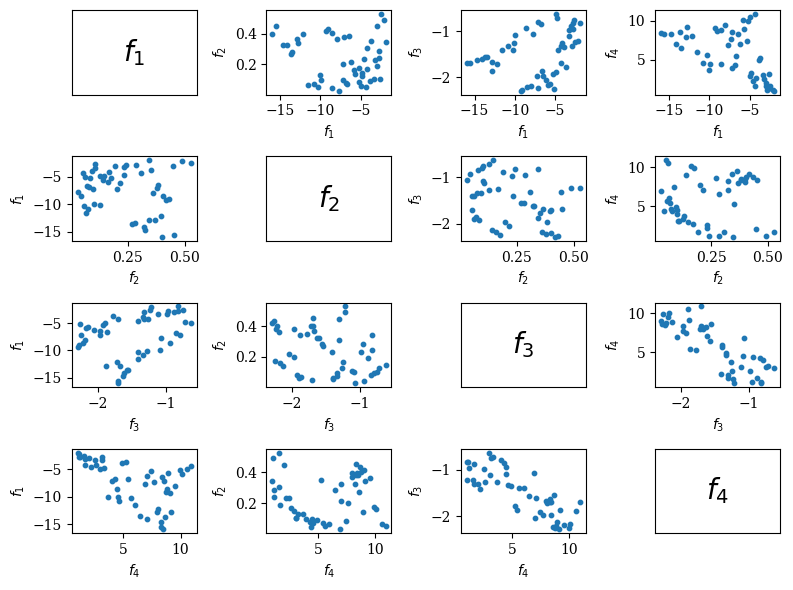

In [5]:
plot = Scatter(tight_layout=True)
plot.add(F, s=10)
# plot.tight_layout()
plot.save('../results/typeG_lvdt_pop50_gen50_n745_scatter.pdf', dpi=300)

### N-D PCP plot

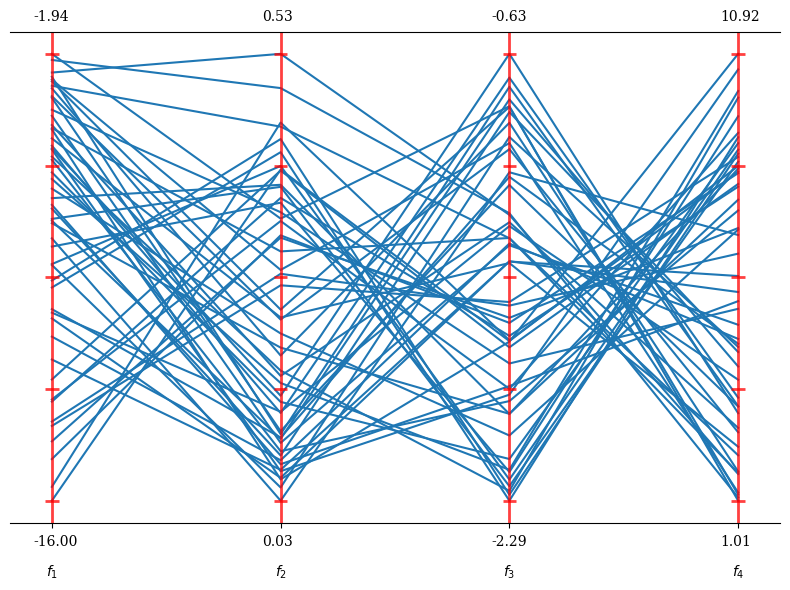

In [6]:
plot = PCP(tight_layout=True)
plot.set_axis_style()
plot.add(F)
plot.save("../results/typeG_lvdt_pop50_gen50_n745_pcp.pdf", dpi=300)


with Recorder(Video("../results/typeG_lvdt_pop50_gen50_n745_pcp.mp4"),) as rec:

    for entry in lvdt_result.history:
        sc = PCP(title =("Gen %s" % entry.n_gen), tight_layout=True)
        sc.add(entry.pop.get("F"))
        sc.add(entry.problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
        sc.do()
        rec.record()

### Convergence plot

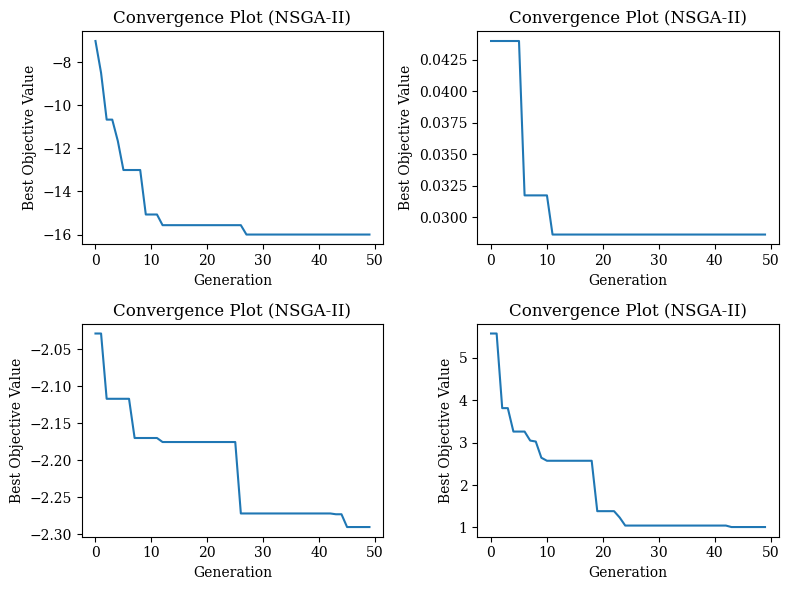

In [7]:
n_gen = len(lvdt_result.history)
f_min_values = [gen.opt.get("F").min(axis=0) for gen in lvdt_result.history]
f_min_values = np.array(f_min_values)  # 转换为 NumPy 数组

plt.figure (figsize=(8,6))
plt.subplot(2, 2, 1)
plt.plot(f_min_values[:, 0], label="Min f1 (Sensitivity)") #  marker = '.', markerfacecolor='none',
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")
plt.subplot(2, 2, 2)
plt.plot(f_min_values[:, 1],  label="Min f2 (Non-linear error)") # marker = '.',markerfacecolor='none',
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")

plt.subplot(2, 2, 3)
plt.plot(f_min_values[:, 2], label="Min f3 (Voice coil force)") # marker = '.',markerfacecolor='none',
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")
plt.subplot(2, 2, 4)
plt.plot(f_min_values[:, 3], label="Min f4 (Force variation index)") # marker = '.',markerfacecolor='none',
plt.xlabel("Generation")
plt.ylabel("Best Objective Value")
plt.title("Convergence Plot (NSGA-II)")
plt.tight_layout()
plt.savefig("../results/typeG_lvdt_pop50_gen50_n745_convergence.pdf", dpi=300)

### Cluster plot

In [8]:
ref_result = {'NLI': 6, 'DI': 14,'LI': 20,'NLO': 7,'DO': 34,'LO': 25,'DIO': 17.5,'f1': -8.42,'f2': 0.48,'f3': -1.85,'f4': 8.86}
column = list(ref_result.keys())
ref_vector = np.array([ref_result[col] for col in column])


params = pd.DataFrame(lvdt_result.X, columns=['NLI', 'DI', 'LI', 'NLO', 'DO', 'LO', 'DIO'])
objectives = pd.DataFrame(lvdt_result.F, columns=['f1', 'f2', 'f3', 'f4']).round(2)
combi_results = pd.concat([params, objectives], axis=1)

combi_results['distance'] = combi_results[column].apply(lambda row: np.linalg.norm(row.values - ref_vector), axis=1).round(2)
closest_rows = combi_results.nsmallest(5, 'distance')
closest_rows['label'] = 'opt'

ref_row = pd.DataFrame([ref_result], columns=column)
ref_row['distance'] = 0.0
ref_row['label'] = 'ref'

finnal_results = pd.concat([ref_row, closest_rows], ignore_index=True)
finnal_results.to_csv('../results/typeG_lvdt_pop50_gen50_n745_results.csv', index=False)